In [297]:
import pandas as pd
import  seaborn as sns
import matplotlib.pyplot as plt
import warnings
%matplotlib inline

In [298]:
df=pd.read_csv('google_cleaned.csv',parse_dates=['Last Updated'])
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day Updated,Month Updated,Year Updated
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000.0,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000000.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,6,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800000.0,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,6,2018


In [299]:
df[df.duplicated('App')].shape

(1181, 16)

The dataset has duplicate records

In [300]:
df=df.drop_duplicates(subset=['App'],keep='first')

In [301]:
df.shape

(9659, 16)

## Explore Data

In [302]:
numerical_features=[feature for feature in df.columns if df[feature].dtype !='O']
categorical_features=[feature for feature in df.columns if df[feature].dtype =='O']
print(f'Numerical features:\ng',numerical_features)
print(f'Categorical features:\n',categorical_features)


Numerical features:
g ['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Last Updated', 'Day Updated', 'Month Updated', 'Year Updated']
Categorical features:
 ['App', 'Category', 'Type', 'Content Rating', 'Genres', 'Current Ver', 'Android Ver']


## Feature information
1.App: The name of the application.  
2.Category: The category under which the app is classified (e.g., Game,Business).  
3.Rating: The average user rating of the app (between 0 and 5).  
4.Reviews: The total number of user reviews for the app.  
5.Size: The size of the app in Bytes.  
6.Installs: The number of times the app has been installed.  
7.Type: Indicates if the app is free or paid.  
8.Price: The cost of the app (if it’s paid).  
9.Content Rating: The age group that the content is appropriate for (e.g., Everyone, Mature).  
10.Genres: The genre of the app (may contain multiple values).  
11.Last Updated: The date when the app was last updated.  
12.Current Version: The current version number of the app.  
13.Android Version: The minimum Android version required to run the app.  

In [303]:
for col in categorical_features:
    print(df[col].value_counts(normalize=True)*100)
    print('-----------------------------')

App
iHoroscope - 2018 Daily Horoscope & Astrology         0.010353
Photo Editor & Candy Camera & Grid & ScrapBook        0.010353
Coloring book moana                                   0.010353
U Launcher Lite – FREE Live Cool Themes, Hide Apps    0.010353
Sketch - Draw & Paint                                 0.010353
                                                        ...   
Learn To Draw Kawaii Characters                       0.010353
3D Color Pixel by Number - Sandbox Art Coloring       0.010353
Mandala Coloring Book                                 0.010353
Tattoo Name On My Photo Editor                        0.010353
Name Art Photo Editor - Focus n Filters               0.010353
Name: proportion, Length: 9659, dtype: float64
-----------------------------
Category
FAMILY                 18.966767
GAME                    9.928564
TOOLS                   8.561963
BUSINESS                4.348276
MEDICAL                 4.089450
PERSONALIZATION         3.892743
PRODUCTIVITY       

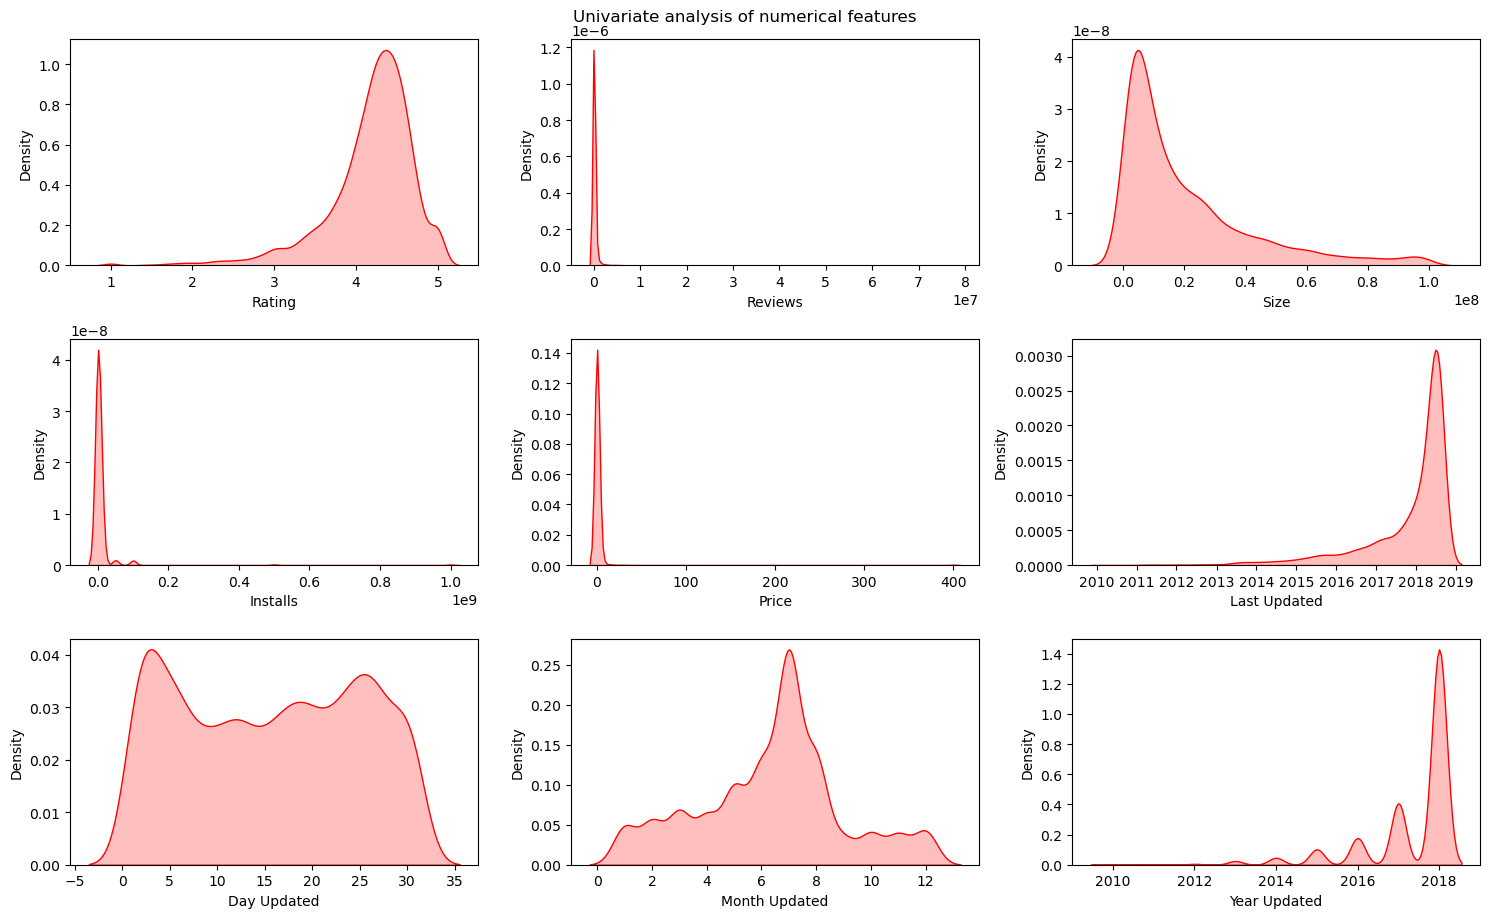

In [304]:
plt.figure(figsize=(15,15))
plt.suptitle('Univariate analysis of numerical features')
for i in range(0,len(numerical_features)):
    plt.subplot(5,3,i+1)
    sns.kdeplot(x=df[numerical_features[i]],fill=True,color='r')
    plt.xlabel(numerical_features[i])
    plt.tight_layout()
plt.show()

## Observation
1.Rating,Last Updated,Rear Updated are left skewed.  
2.Reviews,Size,Installs,Price are right skewed.  
Conclusion:Outliers are present.


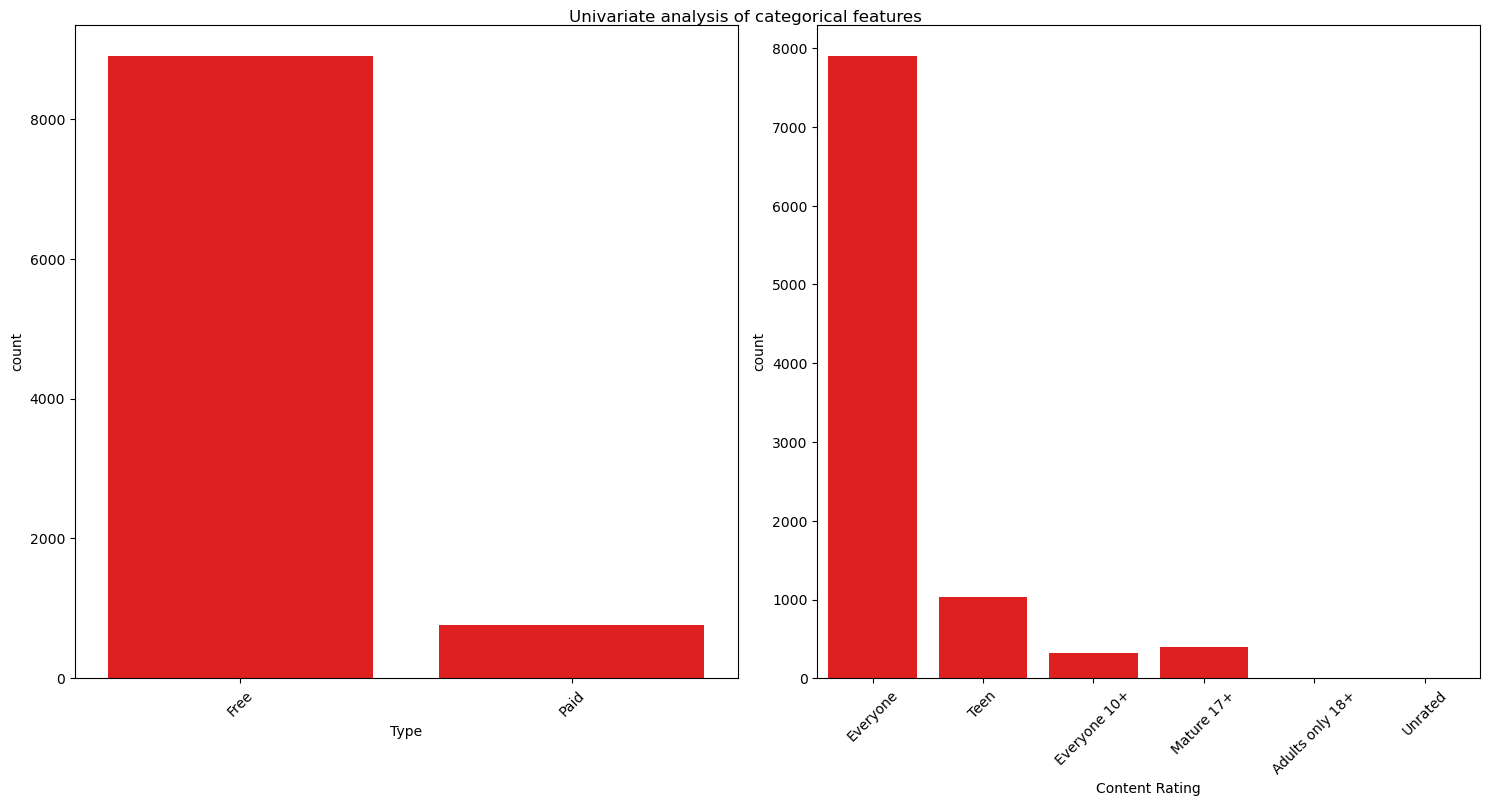

In [305]:
plt.figure(figsize=(15,15))
plt.suptitle('Univariate analysis of categorical features')
category=['Type','Content Rating']
for i in range(0,len(category)):
    plt.subplot(2,2,i+1)
    sns.countplot(x=df[category[i]],color='r')
    plt.xlabel(category[i])
    plt.xticks(rotation=45)
    plt.tight_layout()
plt.show()

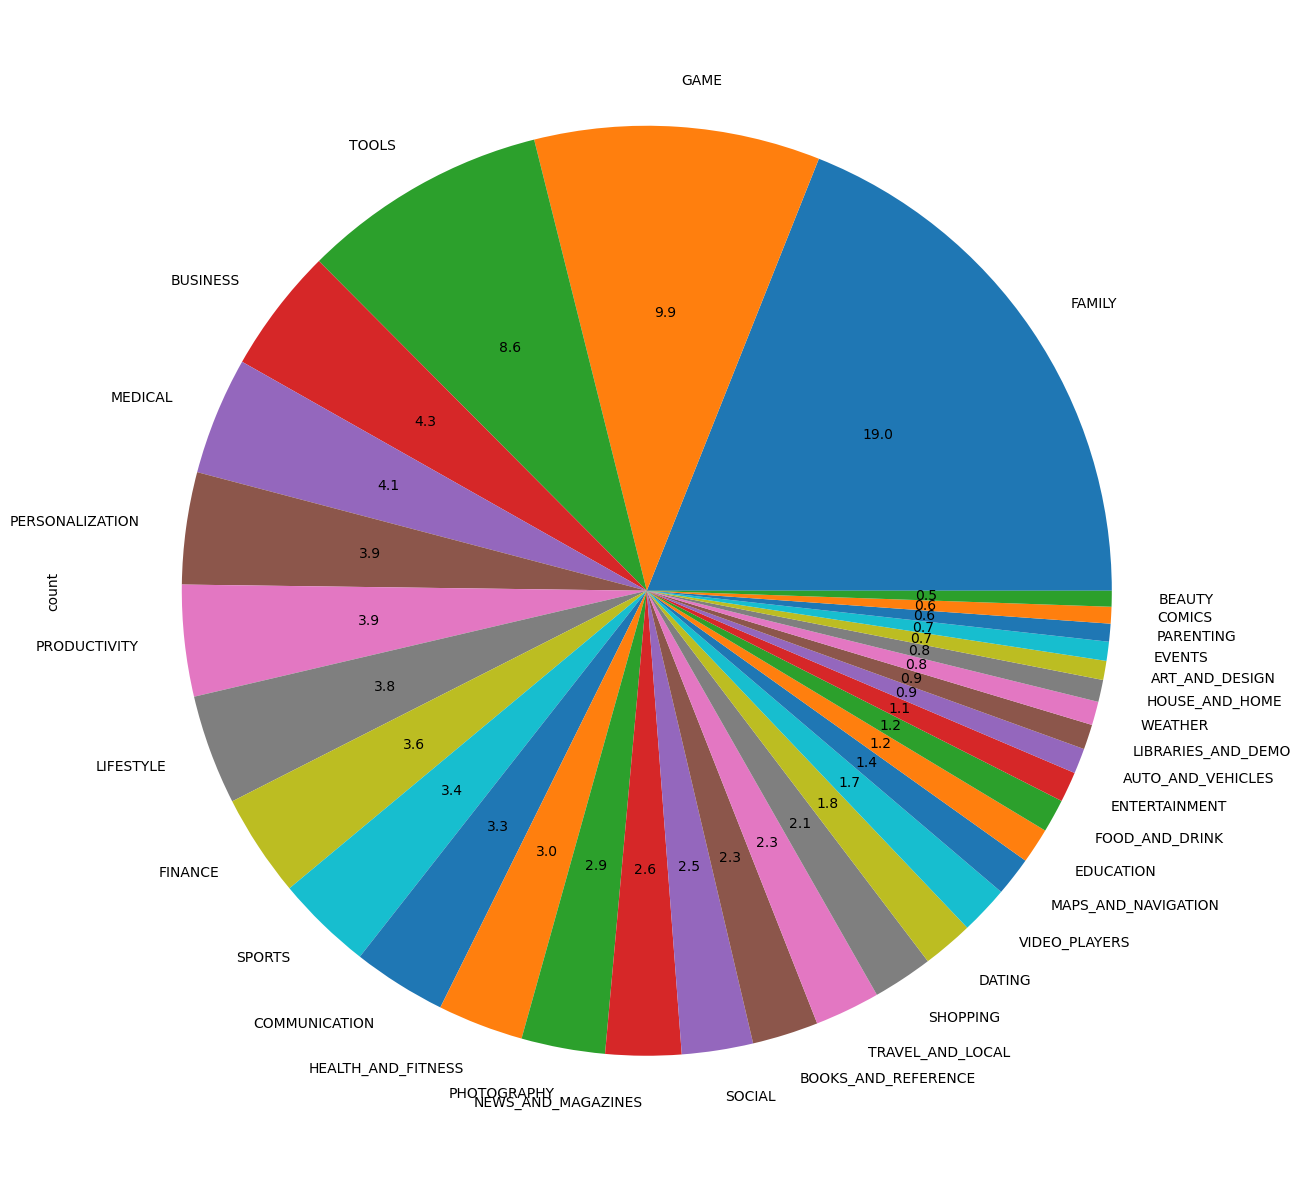

In [306]:
df['Category'].value_counts().plot.pie(y=df['Category'],figsize=(15,16),autopct='%1.1f')
plt.show()

## Observation
They are more types of apps in playstore which are under category of family,games and tools.  
Beauty,Comics,Parenting and Events apps are very less in playstore.

In [ ]:
category = df['Category'].value_counts().reset_index()
category.columns = ['Category', 'Count']
category.head()

,Category,Count
0,FAMILY,1832
1,GAME,959
2,TOOLS,827
3,BUSINESS,420
4,MEDICAL,395


C:\Users\faith\AppData\Local\Temp\ipykernel_18644\3239915910.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


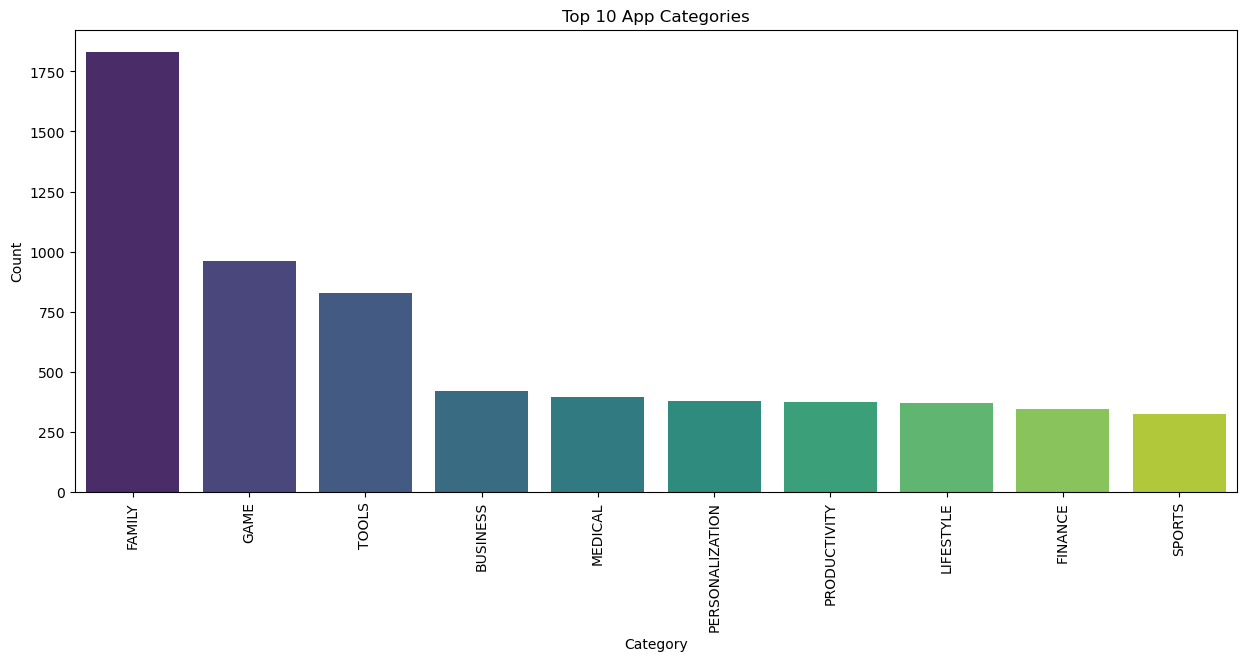

In [335]:
plt.figure(figsize=(15,6))

sns.barplot(
    x='Category',
    y='Count',
    data=category[:10],
    palette='viridis'
)

plt.title('Top 10 App Categories')
plt.xticks(rotation=90)
plt.show()

## Insights
1.Family category has the most numbe rof apps followed by Games category.  
2.Lest numbe rof apps belong to the beauty category.

Which category has largest numbe rof installation?  
Which are top most installed apps in each popular categories?  
How many apps are there on google playstore which get 5 rtings?
  
